In [1]:
import os
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress
import networkx as nx

### Inputs

In [2]:
# Results directory
results_directory = '../../results/v10_1_results/'
output_directory= './timeseries_plots/'
geodata= pd.read_csv('../../model_v10_3/GeoData.txt', index_col=0, sep='\t')
subbasin_id= 58308

In [3]:
def extract_ensemble(results_directory: str, subbasin_id: str, variable, exclude_members=True):
    """
    Extracts ensemble data from files, filters by subbasin ID, and optionally excludes members not found in the offical ensemble.

    Parameters:
        results_directory (str): Path to the directory containing result files.
        subbasin_id (str): Identifier for filtering files belonging to a specific subbasin.
        exclude_members (bool): If True, excludes specified model members.

    Returns:
        xarray.DataArray: Combined ensemble data as an xarray DataArray.
    """
    # List of model names to exclude (not in official ensemble)
    exclude_models = [
        'CanESM5', 'CNRM-CM6-1', 'EC-Earth3', 'IPSL-CM6A-LR',
        'UKESM1-0-LL', 'NorESM2-MM', 'EC-Earth3-CC', 'NESM3',
        'EC-Earth3-Veg', 'INM-CM4-8', 'TaiESM1'
    ]
    
    # Check for files of required subbasin_id
    file_list = [os.path.join(results_directory, filename) for filename in os.listdir(results_directory)
                 if subbasin_id in filename]  # Only filter by subbasin_id
    
    # Create an empty list to store xarray DataArrays
    data_arrays: List[xr.DataArray] = []
    member_names = []  # To store the 'name' of each DataArray for concatenation

    # Loop through each file
    for file_path in file_list:
        # Extract the filename without extension to use as the member name
        member_name = os.path.splitext(os.path.basename(file_path))[0]

        # Conditionally exclude models if exclude_members is True
        if exclude_members and (any(excluded in member_name for excluded in exclude_models) or 'ssp585' in member_name):
            continue
        
        # Read the file into a pandas DataFrame
        df = pd.read_csv(file_path, sep='\t', index_col=0, low_memory=False)

        # Drop the first row to remove units
        df = df.iloc[1:]

        df= df[[variable]]
        
    #    print(df)

        # Convert the DataFrame to an xarray DataArray
        data_array = xr.DataArray(df.values, dims=('DATE', 'variable'),
                                  coords={'DATE': df.index, 'variable': df.columns})
        
        # Assign the filename as the name of the DataArray
        data_array.name = member_name
        
        # Append the DataArray to the list
        data_arrays.append(data_array)
        member_names.append(member_name)  # Keep track of the member name

    # Check if any valid data arrays exist
    if not data_arrays:
        return xr.DataArray()  # Return an empty DataArray if no valid members are left
    
    # Concatenate the list of DataArrays along dimension 'member'
    ds = xr.concat(data_arrays, dim='member')
    
    # Add the member names as a coordinate
    ds.coords['member'] = ('member', member_names)

    # Convert 'DATE' coordinate to datetime, specifying the format and handling errors
    ds['DATE'] = pd.to_datetime(ds['DATE'], format='%Y-%m-%d', errors='coerce')

    # Select the specified variable from the dataset
    var_data = ds.sel(variable=variable)

    # Convert data to numeric
    var_data = var_data.astype(float)
    
    return var_data

In [4]:
def extract_timeoutputs(results_directory: str, variable, exclude_members=True, id_list=None, subbasin_area=None, total_upstream_area=None):
    import os
    import pandas as pd
    import xarray as xr
    from typing import List

    exclude_models = [
        'CanESM5', 'CNRM-CM6-1', 'EC-Earth3', 'IPSL-CM6A-LR',
        'UKESM1-0-LL', 'NorESM2-MM', 'EC-Earth3-CC', 'NESM3',
        'EC-Earth3-Veg', 'INM-CM4-8', 'TaiESM1'
    ]
    
    file_list = [os.path.join(results_directory, filename) for filename in os.listdir(results_directory)
                 if variable in filename]
    
    data_arrays: List[xr.DataArray] = []
    member_names = []

    for file_path in file_list:
        member_name = os.path.splitext(os.path.basename(file_path))[0]

        if exclude_members and (any(excluded in member_name for excluded in exclude_models) or 'ssp585' in member_name):
            continue
        
        try:
            df = pd.read_csv(file_path, sep='\t', index_col=0, low_memory=False, skiprows=1)

            # Drop columns that contain -9999
            df = df.loc[:, ~(df == -9999).any()]

            # Keep only columns in id_list if provided
            if id_list is not None:
                df.columns = df.columns.astype(int)
                id_list_int = [int(x) for x in id_list]
                df = df.loc[:, df.columns.isin(id_list_int)]
                if df.empty:
                    continue  # Skip if nothing remains after filtering

            # Multiply each column by the corresponding area value
            con = df.mul(pd.Series(subbasin_area), axis=1).copy()

            # Find total contributing area (CA) for each timestep
            con['total_ca'] = con.sum(axis=1)

            # Calculate total fraction contributing area (FCA)
            con['total_fca'] = con['total_ca'] / total_upstream_area

            # Keep only the 'total_fca' column
            con = con[['total_fca']]

            # Convert index to datetime
            con.index = pd.to_datetime(con.index, errors='coerce')

            # Resample 'total_fca' to monthly mean
            con_resampled = con['total_fca'].resample("ME").mean()

            # Convert to DataArray
            data_array = xr.DataArray(con_resampled.values, dims=('DATE',),
                                      coords={'DATE': con_resampled.index})
            data_array.name = member_name

            data_arrays.append(data_array)
            member_names.append(member_name)
        
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
            continue

    if not data_arrays:
        return xr.DataArray()

    ds = xr.concat(data_arrays, dim='member')
    ds.coords['member'] = ('member', member_names)

    return ds


In [5]:
def plot_streamflow_time_series(data_array, location, output_directory, date_range=None, log_y=False):
    """
    Plots the ensemble median with a 95% confidence interval shading.
    
    Parameters:
    - data_array (xarray.DataArray): The input data array with dimensions ('DATE', 'member').
    - date_range (tuple, optional): A tuple (start_date, end_date) to filter the data.
    - log_y (bool, optional): If True, sets the y-axis to a logarithmic scale.
    """
    # Convert data to numeric if necessary
    data_array = data_array.astype(float)

    # Filter by date range if provided
    if date_range:
        start_date, end_date = date_range
        data_array = data_array.sel(DATE=slice(start_date, end_date))

    # Compute median and percentiles
    median = data_array.median(dim="member")
    lower_bound = data_array.quantile(0.025, dim="member")
    upper_bound = data_array.quantile(0.975, dim="member")

    # Create plot
    plt.figure(figsize=(18, 4))
    
    # Plot shaded confidence interval
    plt.fill_between(
        data_array['DATE'].values,
        lower_bound,
        upper_bound,
        color='blue',
        alpha=0.2,
        label="95% Confidence Interval"
    )

    # Plot median line with a thinner linewidth
    plt.plot(data_array['DATE'], median, color='blue', linestyle='-', linewidth=1, label="Ensemble Median")

    # Set logarithmic y-axis if requested
    if log_y:
        plt.yscale("log")

    # Customize plot
    plt.xlabel("Time")
    plt.ylabel("Streamflow (cms)")
    plt.title(f"Streamflow Timeseries at {location}")
    plt.legend()
    plt.grid(True)

        # Save plot if output directory is provided
    if output_directory:
        os.makedirs(output_directory, exist_ok=True)
        filename = f"{location}_streamflow_timeseries.png"
        filepath = os.path.join(output_directory, filename)
        plt.savefig(filepath, dpi=300, bbox_inches="tight")
        print(f"Plot saved to {filepath}")

    
    # Show plot
    plt.show()

### Contributing Area

In [6]:
# Convert columns to string data type
geodata['maindown'] = geodata['maindown'].astype(int)
geodata.index= geodata.index.astype(int)

# Create a dictionary with subbasin ID and area
subbasin_area = geodata["area"].to_dict()

In [7]:
# Assuming `geodata` is already defined
# Create a directed graph
riv_graph = nx.DiGraph()

# Add edges from DataFrame
for idx, row in geodata.iterrows():
    if row['maindown'] != '0':  # Skip if maindown is '0'
        riv_graph.add_edge(idx, row['maindown'])

# Find upstream segments for the given segment
upstream_segments = list(nx.ancestors(riv_graph, subbasin_id))

# Add the target segment 'riv_seg' to the upstream segments
upstream_segments.append(subbasin_id)

print(f'{subbasin_id}: {upstream_segments}')

# Get the total area upstream of gauge
total_upstream_area = sum(subbasin_area[key] for key in upstream_segments if key in subbasin_area)

total_upstream_area / 1e6

58308: [58626, 58498, 58630, 58633, 58377, 58507, 58379, 58508, 58639, 58383, 58385, 58643, 58620, 58645, 58646, 58647, 58520, 58521, 58649, 58656, 58658, 58623, 58660, 58661, 58534, 58408, 58541, 58543, 58544, 58421, 58557, 58434, 58309, 58311, 58567, 58574, 58319, 58322, 58323, 58578, 58325, 58330, 58331, 58335, 58593, 58597, 58343, 58474, 58607, 58609, 58354, 58485, 58492, 58621, 58495, 58308]


6503.564399132602

In [8]:
# Extracts 
milk_CA= extract_timeoutputs(results_directory,'FCON', True, upstream_segments, subbasin_area, total_upstream_area)

In [9]:
# Trim to years 2015–2100
trimmed_da = milk_CA.sel(DATE=slice("2015", "2100"))

# Take the mean across the 'member' dimension
mean_da = trimmed_da.mean(dim="member")

In [10]:
df = mean_da.to_dataframe(name='fcon')
df= df[['fcon']]

In [11]:
df

,fcon
DATE,
2015-01-31,0.314136
2015-02-28,0.350560
2015-03-31,0.344482
2015-04-30,0.266387
2015-05-31,0.209677
...,...
2100-08-31,0.169834
2100-09-30,0.177587
2100-10-31,0.201969


In [12]:
df.to_csv('fcon_mean_timeseries_2015_2100.csv')

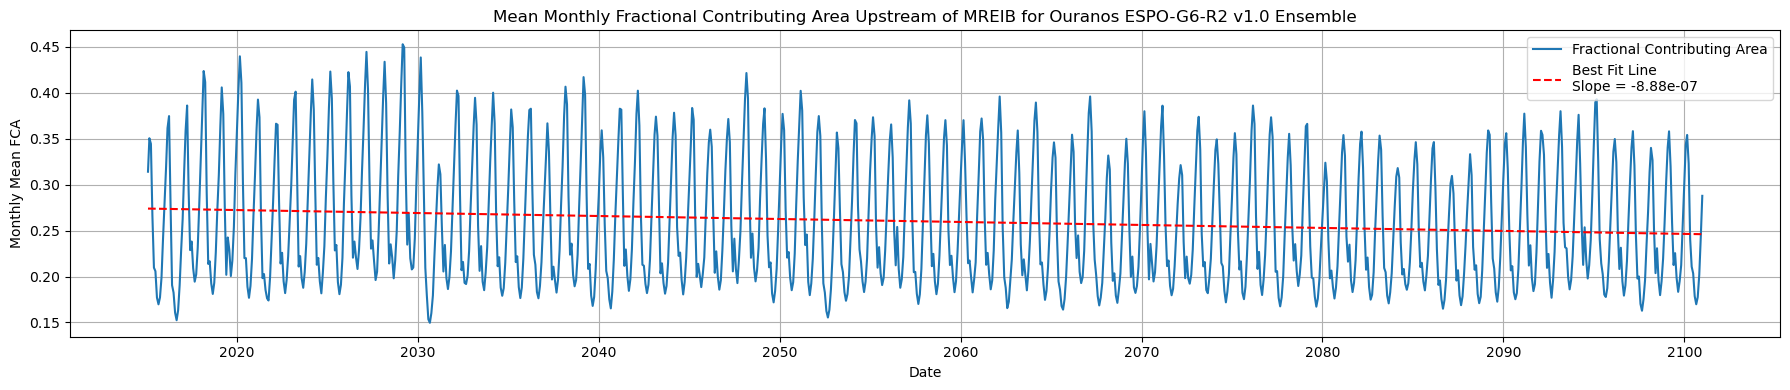

In [13]:
# Convert to pandas Series for easier handling
series = mean_da.to_series()

# Convert dates to ordinal for regression
x = series.index.map(pd.Timestamp.toordinal).values
y = series.values

# Fit a linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Best fit line
y_fit = slope * x + intercept

# Plotting
plt.figure(figsize=(18, 4))
plt.plot(series.index, y, label='Fractional Contributing Area')
plt.plot(series.index, y_fit, color='red', linestyle='--', label=f'Best Fit Line\nSlope = {slope:.2e}')
plt.xlabel('Date')
plt.ylabel('Monthly Mean FCA')
plt.title('Mean Monthly Fractional Contributing Area Upstream of MREIB for Ouranos ESPO-G6-R2 v1.0 Ensemble')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Streamflow

In [14]:
# Extract the streamflow ensembles
milk_official_ensemble= extract_ensemble(results_directory, '58308', 'cout', True)
stm_official_ensemble= extract_ensemble(results_directory, '58208', 'cout', True)

In [15]:
milk_official_ensemble

<xarray.DataArray '56_0058308_outs_CSIRO-ARCCSS_ACCESS-CM2_ssp245' (member: 30,
                                                                    DATE: 55152)> Size: 13MB
array([[1.086, 2.618, 3.585, ..., 3.785, 4.399, 4.806],
       [1.023, 2.505, 3.444, ..., 0.697, 0.669, 0.655],
       [0.79 , 2.616, 5.527, ..., 0.583, 0.626, 0.692],
       ...,
       [0.757, 2.465, 5.128, ..., 2.347, 2.392, 2.507],
       [1.016, 2.838, 5.023, ..., 2.815, 3.146, 3.397],
       [1.007, 2.835, 5.032, ..., 8.404, 8.29 , 8.028]])
Coordinates:
    variable  <U4 16B 'cout'
  * member    (member) <U47 6kB '56_0058308_outs_CSIRO-ARCCSS_ACCESS-CM2_ssp2...
  * DATE      (DATE) datetime64[ns] 441kB 1950-01-01 1950-01-02 ... 2100-12-31

Plot saved to ./timeseries_plots/MREIB_streamflow_timeseries.png


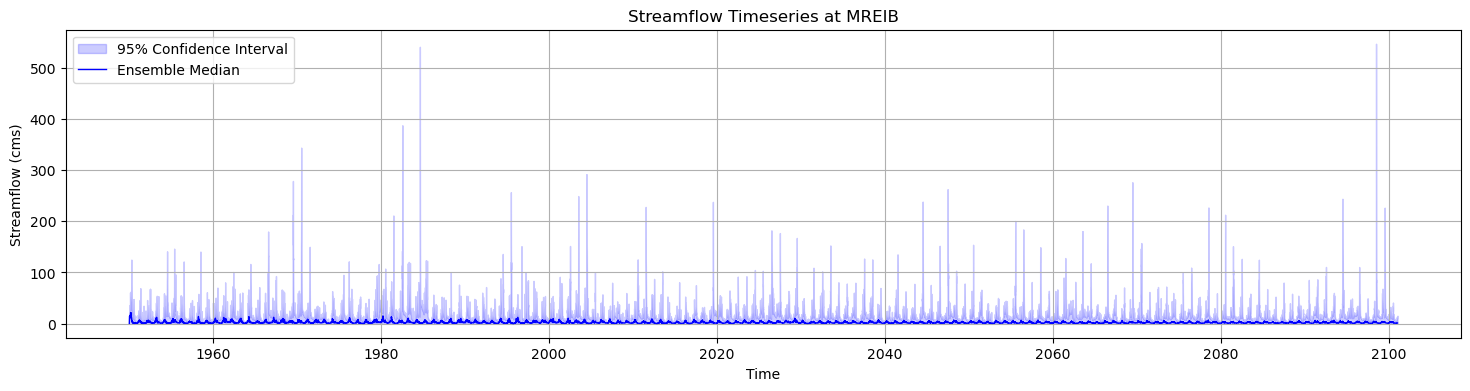

In [16]:
# Plot Milk River streamflow timeseries
plot_streamflow_time_series(milk_official_ensemble, 'MREIB', output_directory, date_range=("1950-01-01", "2100-12-31"), log_y=False)

Plot saved to ./timeseries_plots/SMRIB_streamflow_timeseries.png


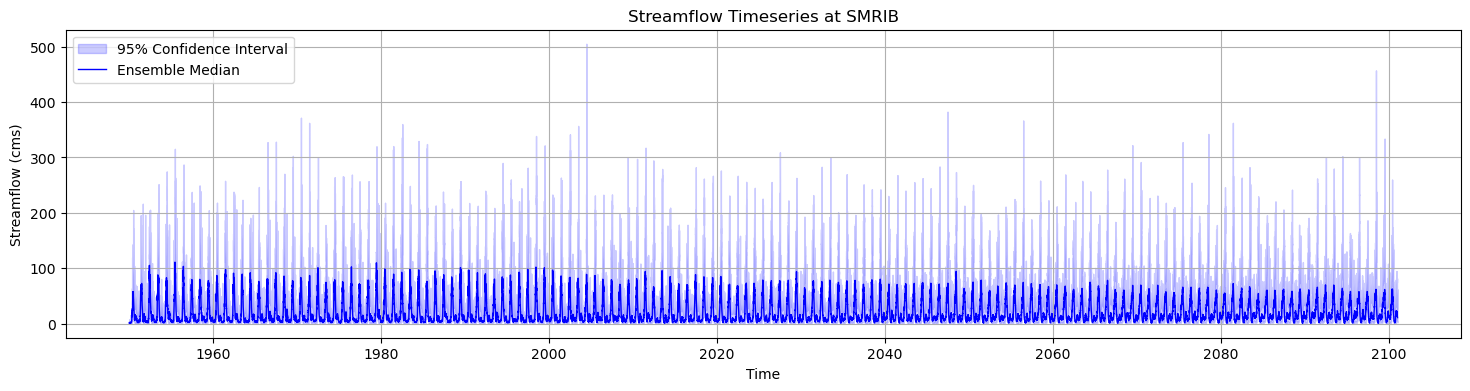

In [17]:
# Plot Milk River streamflow timeseries
plot_streamflow_time_series(stm_official_ensemble, 'SMRIB', output_directory, date_range=("1950-01-01", "2100-12-31"), log_y=False)